<a href="https://colab.research.google.com/github/salih-salu/Loan_Approval_prediction_Machine_learning/blob/main/Load_approval_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

In [93]:
df = pd.read_csv('/content/loan_data_1.csv')

In [94]:
df.isna().sum()

,0
Text,0
Income,0
Credit_Score,3
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [95]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
23995,False
23996,False
23997,False
23998,False


In [96]:
df

,Text,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,I need a loan to pay for an international vaca...,26556,581.0,8314,79.26,employed,Rejected
1,I want to make home improvements like installi...,197392,389.0,111604,22.14,employed,Rejected
2,"I need a loan for home renovation, including a...",44561,523.0,34118,45.44,employed,Rejected
3,I need funds to buy new furniture and applianc...,190363,729.0,118757,10.22,unemployed,Rejected
4,I need a loan to start a small business.,61853,732.0,19210,44.13,employed,Approved
...,...,...,...,...,...,...,...
23995,I need funds to pay for my daughter's college ...,195242,817.0,16403,24.32,employed,Approved
23996,I need financial assistance to launch my own Y...,150246,729.0,101572,9.97,employed,Rejected
23997,I need money to open a small bookstore and café.,64571,650.0,30533,57.35,employed,Rejected
23998,I want to buy a car for my rideshare business ...,115825,418.0,89837,10.37,unemployed,Rejected


In [97]:
df.drop(columns='Text', inplace=True)

In [98]:
df

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status,Approval
0,26556,581.0,8314,79.26,employed,Rejected
1,197392,389.0,111604,22.14,employed,Rejected
2,44561,523.0,34118,45.44,employed,Rejected
3,190363,729.0,118757,10.22,unemployed,Rejected
4,61853,732.0,19210,44.13,employed,Approved
...,...,...,...,...,...,...
23995,195242,817.0,16403,24.32,employed,Approved
23996,150246,729.0,101572,9.97,employed,Rejected
23997,64571,650.0,30533,57.35,employed,Rejected
23998,115825,418.0,89837,10.37,unemployed,Rejected


In [99]:
df.isna().sum()

,0
Income,0
Credit_Score,3
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [100]:
df['Credit_Score'] = df['Credit_Score'].fillna(df['Credit_Score'].mean())

In [101]:
df.isna().sum()

,0
Income,0
Credit_Score,0
Loan_Amount,0
DTI_Ratio,0
Employment_Status,0
Approval,0


In [102]:
df['Employment_Status'].unique()

array(['employed', 'unemployed'], dtype=object)

In [103]:
lb = LabelEncoder()
df['Employment_Status'] = lb.fit_transform(df['Employment_Status'])


In [104]:
df['Approval'] = lb.fit_transform(df['Approval'])

In [105]:
df['Approval'].value_counts()

,count
Approval,
1,20067
0,3933


In [106]:
X = df.iloc[:, :-1]
X

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status
0,26556,581.0,8314,79.26,0
1,197392,389.0,111604,22.14,0
2,44561,523.0,34118,45.44,0
3,190363,729.0,118757,10.22,1
4,61853,732.0,19210,44.13,0
...,...,...,...,...,...
23995,195242,817.0,16403,24.32,0
23996,150246,729.0,101572,9.97,0
23997,64571,650.0,30533,57.35,0
23998,115825,418.0,89837,10.37,1


In [107]:
# y = df['Approval']
y = df.iloc[:,-1]
y

,Approval
0,1
1,1
2,1
3,1
4,0
...,...
23995,0
23996,1
23997,1
23998,1


#Balance the data using SMOTE

In [108]:
smote = SMOTE()
X, y = smote.fit_resample(X, y)

In [109]:
X

,Income,Credit_Score,Loan_Amount,DTI_Ratio,Employment_Status
0,26556,581.000000,8314,79.260000,0
1,197392,389.000000,111604,22.140000,0
2,44561,523.000000,34118,45.440000,0
3,190363,729.000000,118757,10.220000,1
4,61853,732.000000,19210,44.130000,0
...,...,...,...,...,...
40129,95717,698.745697,6311,26.925783,0
40130,141949,657.704189,57191,19.425940,0
40131,100435,629.538541,37249,37.900115,0
40132,31349,591.032052,16567,22.930928,0


In [110]:
y.value_counts()

,count
Approval,
1,20067
0,20067


#standardize the input features

In [111]:
scaler = StandardScaler()
X = scaler.fit_transform(X)
X

array([[-1.81419022, -0.31359347, -1.05304984,  1.86717475, -0.65336452],
       [ 1.62137117, -1.63894123,  2.1981721 , -0.28266852, -0.65336452],
       [-1.45210446, -0.71395894, -0.24082667,  0.59428086, -0.65336452],
       ...,
       [-0.32846216,  0.02146094, -0.14227332,  0.31049986, -0.65336452],
       [-1.71780161, -0.24434369, -0.79327315, -0.2529001 , -0.65336452],
       [-0.33405282,  0.27001422, -0.29493501, -0.72215168, -0.65336452]])

# Data Splitting for model train and test

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [113]:
X_train.shape,y_train.shape, X_test.shape, y_test.shape

((28093, 5), (28093,), (12041, 5), (12041,))

#Model development

In [114]:
model = KNeighborsClassifier(n_neighbors=7)

In [115]:
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=7)

#Prediction using testing data

In [116]:
y_pred = model.predict(X_test)

In [117]:
y_pred

array([1, 0, 0, ..., 0, 1, 1])

#Model Evaluation

#Accuracy

In [118]:
accu = accuracy_score(y_test, y_pred)
accu

0.9871273150070592

#Confusion matrics

In [119]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[6058,    5],
       [ 150, 5828]])

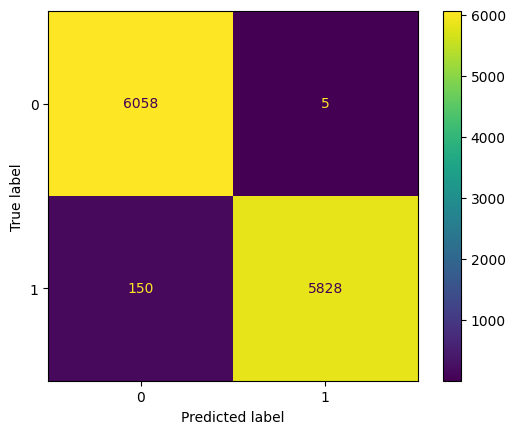

In [120]:
cmd = ConfusionMatrixDisplay(cm)
cmd.plot()

In [121]:
crp = classification_report(y_test, y_pred)
print(crp)

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      6063
           1       1.00      0.97      0.99      5978

    accuracy                           0.99     12041
   macro avg       0.99      0.99      0.99     12041
weighted avg       0.99      0.99      0.99     12041

